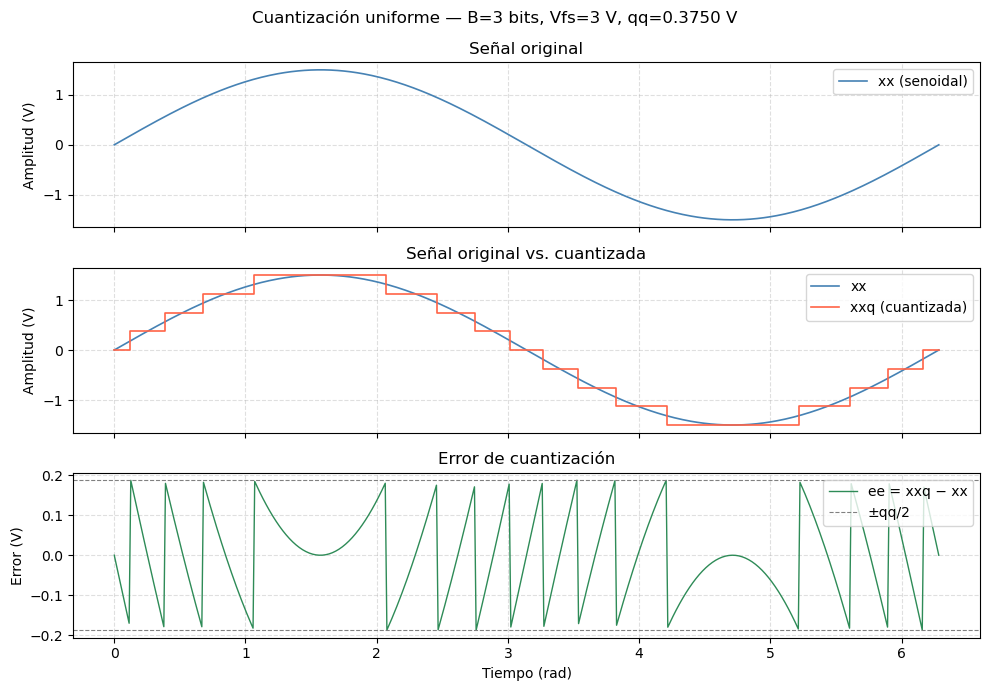

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de cuantización
B   = 3
Vfs = 3
qq  = Vfs / 2**B

# Señal senoidal original
N  = 500
tt = np.linspace(0, 2 * np.pi, N)
xx = (Vfs / 2) * np.sin(tt)   # amplitud ≤ Vfs/2

# Cuantización
xxq = np.round(xx / qq) * qq
ee  = xxq - xx              # error de cuantización

# ── Figura con 3 subplots ──────────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f"Cuantización uniforme — B={B} bits, Vfs={Vfs} V, qq={qq:.4f} V",
             fontsize=12)

# --- Subplot 1: señal original ---
axs[0].plot(tt, xx, color="steelblue", linewidth=1.2, label="xx (senoidal)")
axs[0].set_ylabel("Amplitud (V)")
axs[0].legend(loc="upper right")
axs[0].grid(True, linestyle="--", alpha=0.4)
axs[0].set_title("Señal original")

# --- Subplot 2: señal original + cuantizada ---
axs[1].plot(tt, xx,  color="steelblue", linewidth=1.2, label="xx")
axs[1].step(tt, xxq, color="tomato",    linewidth=1.2,
          where="mid", label="xxq (cuantizada)")
axs[1].set_ylabel("Amplitud (V)")
axs[1].legend(loc="upper right")
axs[1].grid(True, linestyle="--", alpha=0.4)
axs[1].set_title("Señal original vs. cuantizada")

# --- Subplot 3: error de cuantización ---
axs[2].plot(tt, ee, color="seagreen", linewidth=1.0, label="ee = xxq − xx")
axs[2].axhline(  qq/2, color="gray", linestyle="--",
               linewidth=0.8, label="±qq/2")
axs[2].axhline( -qq/2, color="gray", linestyle="--", linewidth=0.8)
axs[2].set_ylabel("Error (V)")
axs[2].set_xlabel("Tiempo (rad)")
axs[2].legend(loc="upper right")
axs[2].grid(True, linestyle="--", alpha=0.4)
axs[2].set_title("Error de cuantización")

plt.tight_layout()
plt.show()

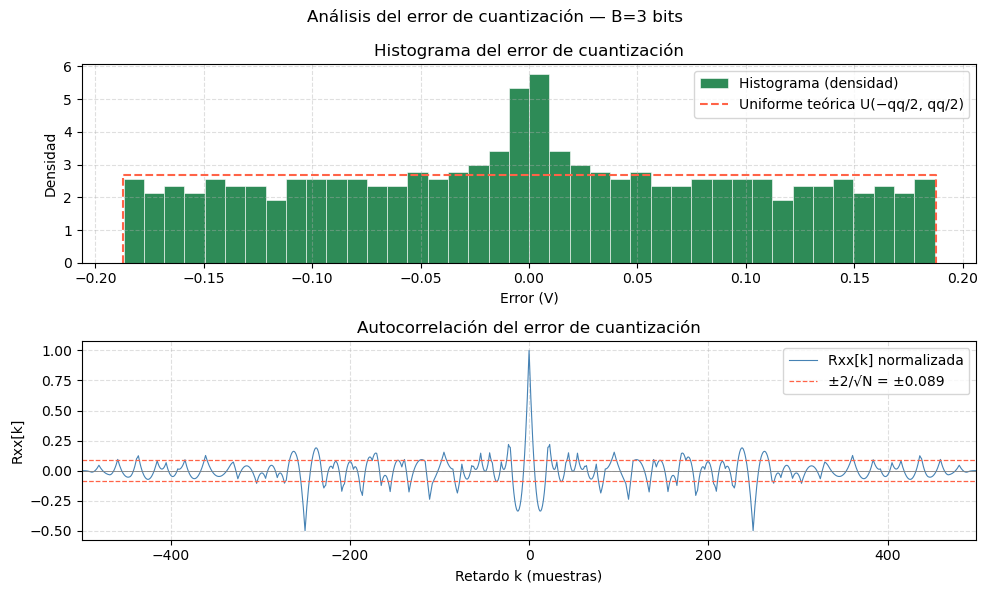

In [ ]:
# ── Histograma + Autocorrelación del error ──────
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 6))
fig2.suptitle(f"Análisis del error de cuantización — B={B} bits",
              fontsize=12)

# --- Subplot 1: Histograma del error ---
n_bins = 40
axs2[0].hist(ee, bins=n_bins, color="seagreen",
              edgecolor="white", linewidth=0.4,
              density=True, label="Histograma (densidad)")

# Referencia: densidad uniforme teórica en [-qq/2, qq/2]
xx_ref = np.array([-qq/2, -qq/2, qq/2, qq/2])
yy_ref = np.array([0, 1/qq, 1/qq, 0])
axs2[0].plot(xx_ref, yy_ref, color="tomato", linewidth=1.5,
             linestyle="--", label="Uniforme teórica U(−qq/2, qq/2)")

axs2[0].set_xlabel("Error (V)")
axs2[0].set_ylabel("Densidad")
axs2[0].legend(loc="upper right")
axs2[0].grid(True, linestyle="--", alpha=0.4)
axs2[0].set_title("Histograma del error de cuantización")

# --- Subplot 2: Autocorrelación del error ---
# Autocorrelación normalizada (lag 0 = 1)
ee_centered = ee - ee.mean()
acorr = np.correlate(ee_centered, ee_centered, mode="full")
acorr = acorr / acorr.max()          # normalizar
lags  = np.arange(-N + 1, N)        # vector de retardos

axs2[1].plot(lags, acorr, color="steelblue",
             linewidth=0.8, label="Rxx[k] normalizada")
axs2[1].axhline(0, color="gray", linewidth=0.6)

# Banda de confianza ±2/√N (ruido blanco)
conf = 2 / np.sqrt(N)
axs2[1].axhline( conf, color="tomato", linestyle="--",
                linewidth=0.9, label=f"±2/√N = ±{conf:.3f}")
axs2[1].axhline(-conf, color="tomato", linestyle="--",
                linewidth=0.9)

axs2[1].set_xlim(-N + 1, N - 1)
axs2[1].set_xlabel("Retardo k (muestras)")
axs2[1].set_ylabel("Rxx[k]")
axs2[1].legend(loc="upper right")
axs2[1].grid(True, linestyle="--", alpha=0.4)
axs2[1].set_title("Autocorrelación del error de cuantización")

plt.tight_layout()
plt.show()


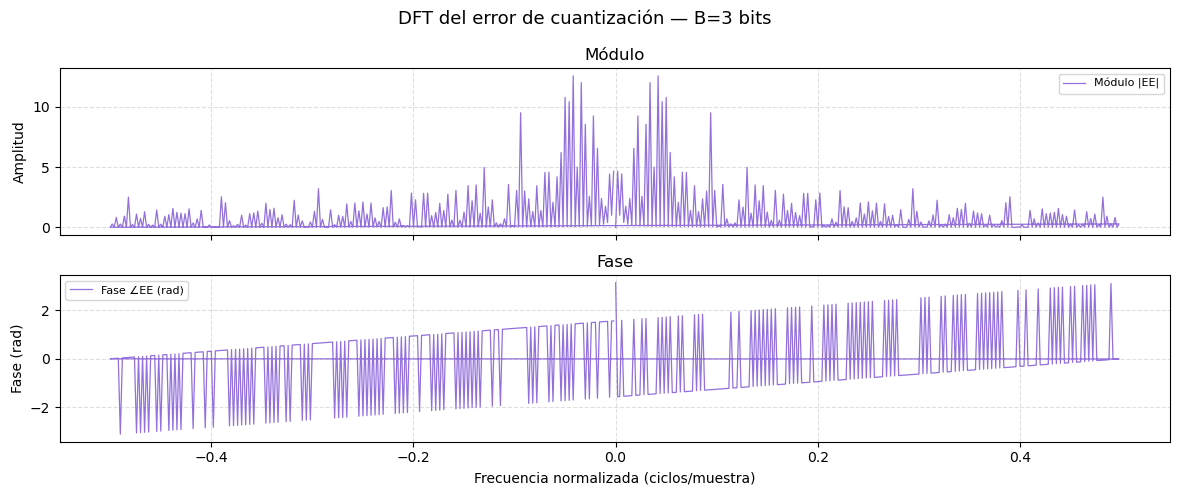

In [5]:
# ── DFT del error de cuantización ───────────────────────── Prueba de concepto no llegue a ver todo lo que comento el profe
EE     = np.fft.fft(ee)
EEmod  = np.abs(EE)
EEphase = np.angle(EE)

# Eje de frecuencias normalizado [0, 1) en ciclos/muestra
freqs = np.fft.fftfreq(N)

fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig3.suptitle(f"DFT del error de cuantización — B={B} bits", fontsize=13)

# --- Módulo ---
ax1.plot(freqs, EEmod, color="mediumpurple",
         linewidth=0.9, label="Módulo |EE|")
ax1.set_ylabel("Amplitud")
ax1.legend(fontsize=8)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.set_title("Módulo")

# --- Fase ---
ax2.plot(freqs, EEphase, color="mediumpurple",
         linewidth=0.9, label="Fase ∠EE (rad)")
ax2.set_ylabel("Fase (rad)")
ax2.set_xlabel("Frecuencia normalizada (ciclos/muestra)")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_title("Fase")

plt.tight_layout()
plt.show()


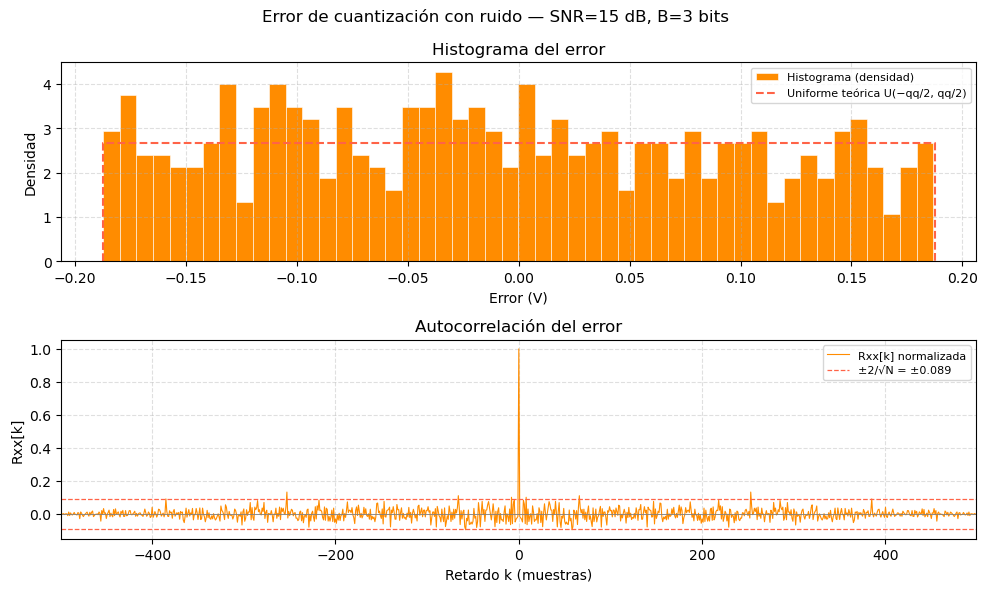

In [10]:
# ── SNR = 15 dB ──────────────────────
SNR_dB  = 15
SNR_lin = 10 ** (SNR_dB / 10)
P_xx    = np.mean(xx**2)
sigma   = np.sqrt(P_xx / SNR_lin)

np.random.seed(42)
xx_noisy  = xx + sigma * np.random.randn(N)
xxq_noisy = np.round(xx_noisy / qq) * qq
ee_noisy  = xxq_noisy - xx_noisy

# ── Figura ────────────────────────────────────────────────
fig4, axs4 = plt.subplots(2, 1, figsize=(10, 6))
fig4.suptitle(f"Error de cuantización con ruido — SNR={SNR_dB} dB, B={B} bits",
              fontsize=12)

# --- Histograma ---
axs4[0].hist(ee_noisy, bins=50, color="darkorange",
              edgecolor="white", linewidth=0.4,
              density=True, label="Histograma (densidad)")
xx_ref = np.array([-qq/2, -qq/2, qq/2, qq/2])
yy_ref = np.array([0, 1/qq, 1/qq, 0])
axs4[0].plot(xx_ref, yy_ref, color="tomato", linewidth=1.5,
             linestyle="--", label="Uniforme teórica U(−qq/2, qq/2)")
axs4[0].set_xlabel("Error (V)")
axs4[0].set_ylabel("Densidad")
axs4[0].legend(fontsize=8)
axs4[0].grid(True, linestyle="--", alpha=0.4)
axs4[0].set_title("Histograma del error")

# --- Autocorrelación ---
ee_c  = ee_noisy - ee_noisy.mean()
acorr = np.correlate(ee_c, ee_c, mode="full")
acorr = acorr / acorr.max()
lags  = np.arange(-N + 1, N)
conf  = 2 / np.sqrt(N)

axs4[1].plot(lags, acorr, color="darkorange",
             linewidth=0.8, label="Rxx[k] normalizada")
axs4[1].axhline(0,    color="gray",  linewidth=0.6)
axs4[1].axhline( conf, color="tomato", linestyle="--",
                linewidth=0.9, label=f"±2/√N = ±{conf:.3f}")
axs4[1].axhline(-conf, color="tomato", linestyle="--", linewidth=0.9)
axs4[1].set_xlim(-N + 1, N - 1)
axs4[1].set_xlabel("Retardo k (muestras)")
axs4[1].set_ylabel("Rxx[k]")
axs4[1].legend(fontsize=8)
axs4[1].grid(True, linestyle="--", alpha=0.4)
axs4[1].set_title("Autocorrelación del error")

plt.tight_layout()
plt.show()


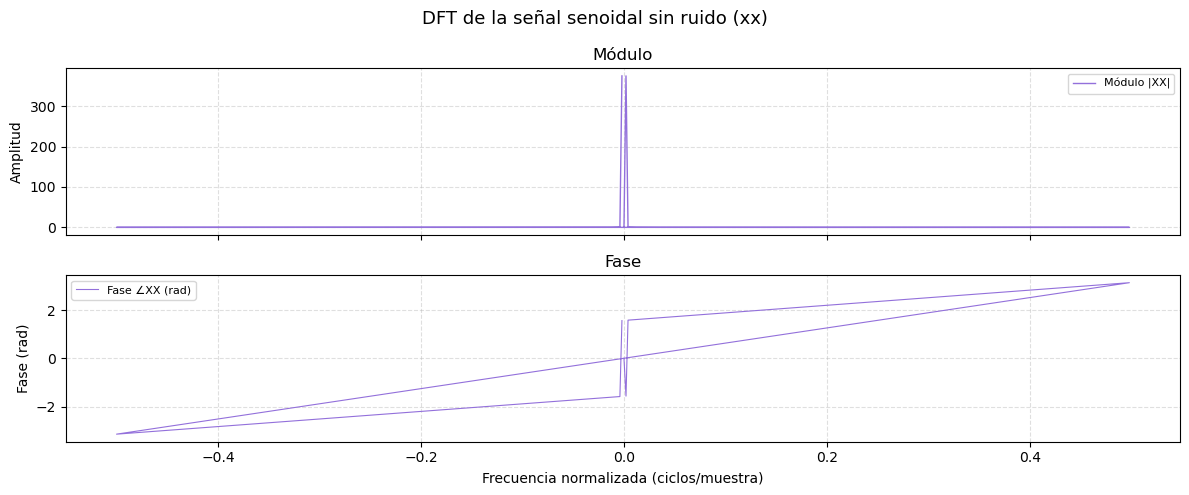

In [11]:
# ── DFT de la señal senoidal limpia ───────────────────────
XX      = np.fft.fft(xx)
XXmod   = np.abs(XX)
XXphase = np.angle(XX)
freqs   = np.fft.fftfreq(N)

fig5, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig5.suptitle("DFT de la señal senoidal sin ruido (xx)", fontsize=13)

ax1.plot(freqs, XXmod, color="mediumpurple",
         linewidth=1, label="Módulo |XX|")
ax1.set_ylabel("Amplitud")
ax1.legend(fontsize=8)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.set_title("Módulo")

ax2.plot(freqs, XXphase, color="mediumpurple",
         linewidth=0.8, label="Fase ∠XX (rad)")
ax2.set_ylabel("Fase (rad)")
ax2.set_xlabel("Frecuencia normalizada (ciclos/muestra)")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_title("Fase")

plt.tight_layout()
plt.show()

In [12]:
print(f"P_xx    = {P_xx:.4f} V²")
print(f"P_noise = {P_xx/SNR_lin:.5f} V²")
print(f"sigma   = {np.sqrt(P_xx/SNR_lin):.4f} V")
print(f"SNR     = {10*np.log10(P_xx/(P_xx/SNR_lin)):.1f} dB")

P_xx    = 1.1227 V²
P_noise = 0.03550 V²
sigma   = 0.1884 V
SNR     = 15.0 dB
